In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# 설정
# -------------------------
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]
NUM_GAMES = 10000

# -------------------------
# 데이터 생성 함수
# -------------------------
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x): # 이 함수에서 정의된 x는 함수안에서 사용되는 지역변수로서 함수 밖에서는 사용할수없다. 함수 호출할때 이 x 자리에 값이 대입된다. 예를 들어 classify_interval(50)이라고 호출하면 x는 50이 되고, classify_interval(150)이라고 호출하면 x는 150이 되는 것이다. 이렇게 함수가 호출될 때마다 x에 다른 값이 들어가면서 함수 내부에서 그 값이 어떤 구간에 속하는지 판단하는 것이다.
    for i, (lo, hi) in enumerate(intervals): # enumerate는 리스트의 요소와 인덱스를 동시에 반환하는 함수이다. 여기서는 intervals 리스트의 각 요소(구간)와 그 인덱스를 i와 (lo, hi)로 받아서 구간 분류를 하는 것이다.
        if lo <= x <= hi:
            return i # 예를 들어 enumerate로 intervals 리스트를 순회할 때, 첫 번째 요소 (1, 28)는 인덱스 0과 함께 반환되고, 두 번째 요소 (29, 64)는 인덱스 1과 함께 반환된다. classify_interval 함수는 입력 x가 어느 구간에 속하는지 확인하고 해당 구간의 인덱스를 반환한다.

def interval_distribution(data, n):
    recent = data[-n:]
    counts = [0] * len(intervals)

    for val in recent:
        idx = classify_interval(val)
        counts[idx] += 1

    return counts

# -------------------------
# 데이터 생성
# -------------------------
X_data = []
y_data = []
jackpot_history = []

for _ in range(NUM_GAMES):
    jackpot_num = make_jackpot_num()
    jackpot_history.append(jackpot_num)

    dist5  = interval_distribution(jackpot_history, 5)
    dist10 = interval_distribution(jackpot_history, 10)
    dist15 = interval_distribution(jackpot_history, 15)
    dist20 = interval_distribution(jackpot_history, 20)

    tokens = [dist5, dist10, dist15, dist20]

    X_data.append(tokens)
    y_data.append(classify_interval(jackpot_num))

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.int64)

# shift (다음 값 예측)
X_data = X_data[:-1]
y_data = y_data[1:]

print("데이터 shape:", X_data.shape, y_data.shape)
for i in range(10):
    print(f"X[{i}] = {X_data[i]}  |  y[{i}] = {y_data[i]}")

데이터 shape: (9999, 4, 5) (9999,)
X[0] = [[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]  |  y[0] = 1
X[1] = [[0. 2. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 2. 0. 0. 0.]]  |  y[1] = 0
X[2] = [[1. 2. 0. 0. 0.]
 [1. 2. 0. 0. 0.]
 [1. 2. 0. 0. 0.]
 [1. 2. 0. 0. 0.]]  |  y[2] = 2
X[3] = [[1. 2. 1. 0. 0.]
 [1. 2. 1. 0. 0.]
 [1. 2. 1. 0. 0.]
 [1. 2. 1. 0. 0.]]  |  y[3] = 3
X[4] = [[1. 2. 1. 1. 0.]
 [1. 2. 1. 1. 0.]
 [1. 2. 1. 1. 0.]
 [1. 2. 1. 1. 0.]]  |  y[4] = 0
X[5] = [[2. 1. 1. 1. 0.]
 [2. 2. 1. 1. 0.]
 [2. 2. 1. 1. 0.]
 [2. 2. 1. 1. 0.]]  |  y[5] = 3
X[6] = [[2. 0. 1. 2. 0.]
 [2. 2. 1. 2. 0.]
 [2. 2. 1. 2. 0.]
 [2. 2. 1. 2. 0.]]  |  y[6] = 4
X[7] = [[1. 0. 1. 2. 1.]
 [2. 2. 1. 2. 1.]
 [2. 2. 1. 2. 1.]
 [2. 2. 1. 2. 1.]]  |  y[7] = 2
X[8] = [[1. 0. 1. 2. 1.]
 [2. 2. 2. 2. 1.]
 [2. 2. 2. 2. 1.]
 [2. 2. 2. 2. 1.]]  |  y[8] = 3
X[9] = [[1. 0. 1. 2. 1.]
 [2. 2. 2. 3. 1.]
 [2. 2. 2. 3. 1.]
 [2. 2. 2. 3. 1.]]  |  y[9] = 4


Flatten shape: (9999, 20)
PCA 결과 shape: (9999, 2)


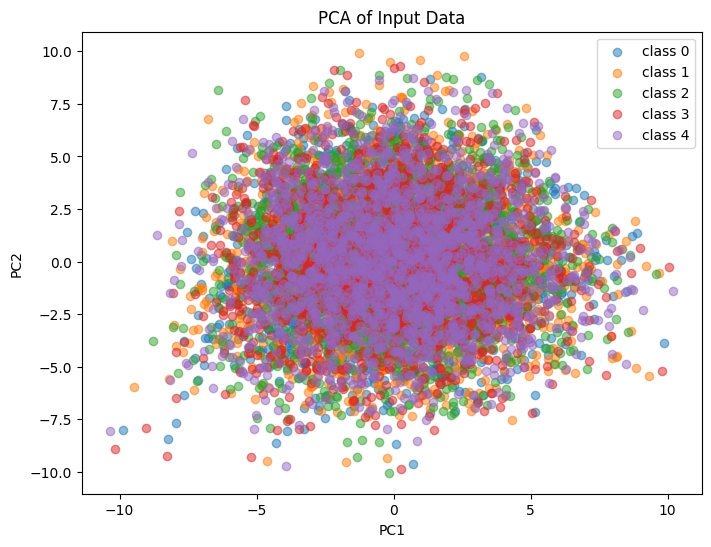

Explained variance ratio: [0.22161634 0.21521735]


In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ flatten (N, 4, 5) → (N, 20)
# -------------------------
X_flat = X_data.reshape(len(X_data), -1)

print("Flatten shape:", X_flat.shape)  # (N, 20)

# -------------------------
# 2️⃣ PCA 수행
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

print("PCA 결과 shape:", X_pca.shape)

# -------------------------
# 3️⃣ 시각화 (label 색칠)
# -------------------------
plt.figure(figsize=(8,6))

for cls in range(5):
    idx = (y_data == cls)
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=f"class {cls}",
        alpha=0.5
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Input Data")
plt.legend()
plt.show()

# -------------------------
# 4️⃣ 설명된 분산 비율 확인
# -------------------------
print("Explained variance ratio:", pca.explained_variance_ratio_)

# 그러나 현재 언어모델 임베딩행렬의 경우 PCA분석 어려울것같은데 중간에 신경망이 적절히 처리해주고 유사한것들은 유사한곳으로 가고 대상자체의 위치까지 변화시켜주기 때문에 가능한것같다
# 그래서 가까운 점들끼리 모이게하는 t sne나 u map이 오히려 임베딩행렬의 유사한 단어들끼리 모아준다고한다.

PCA shape: (9999, 3)


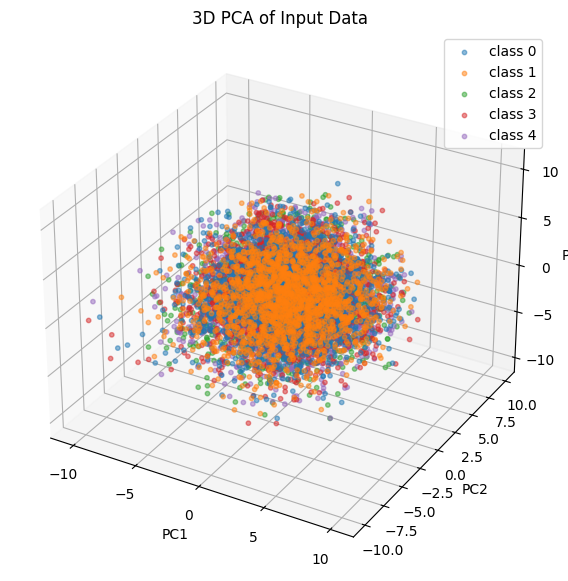

Explained variance ratio: [0.22161634 0.21521735 0.2031376 ]
총 설명 비율: 0.63997126


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting

# -------------------------
# 1️⃣ flatten (N, 4, 5) → (N, 20)
# -------------------------
X_flat = X_data.reshape(len(X_data), -1)

# -------------------------
# 2️⃣ PCA (3차원)
# -------------------------
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_flat)

print("PCA shape:", X_pca.shape)

# -------------------------
# 3️⃣ 3D 시각화
# -------------------------
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

colors = ['blue', 'orange', 'green', 'red', 'purple']

for cls in range(5):
    idx = (y_data == cls)
    ax.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        X_pca[idx, 2],
        label=f"class {cls}",
        alpha=0.5,
        s=10
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA of Input Data")
ax.legend()

plt.show()

# -------------------------
# 4️⃣ 분산 비율
# -------------------------
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 비율:", sum(pca.explained_variance_ratio_))

t-SNE shape: (9999, 2)


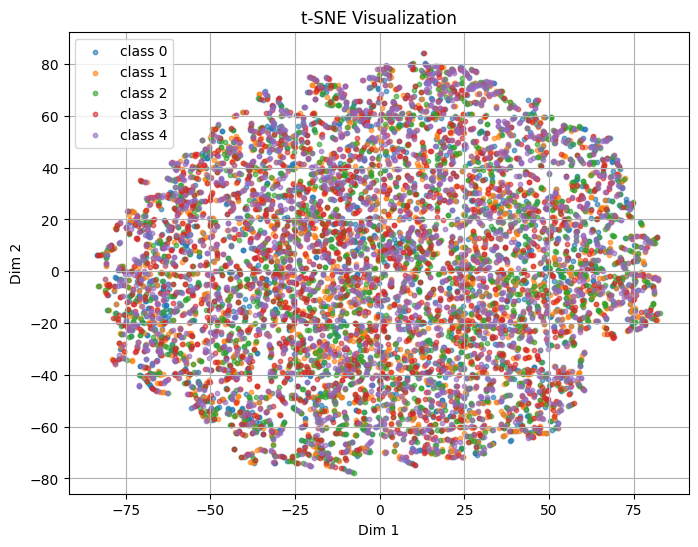

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ flatten
# -------------------------
X_flat = X_data.reshape(len(X_data), -1)

# -------------------------
# 2️⃣ t-SNE
# -------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,     # 기본값, 5~50 사이 조절 가능
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_flat)

print("t-SNE shape:", X_tsne.shape)

# -------------------------
# 3️⃣ 시각화
# -------------------------
plt.figure(figsize=(8,6))

for cls in range(5):
    idx = (y_data == cls)
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=f"class {cls}",
        alpha=0.6,
        s=10
    )

plt.title("t-SNE Visualization")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid()
plt.show()

X shape: (150, 4)
y shape: (150,)
PCA 결과 shape: (150, 2)


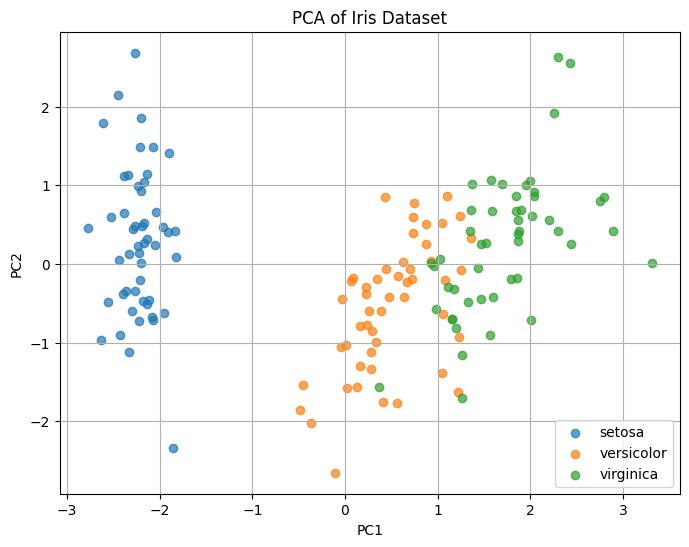

Explained variance ratio: [0.72962445 0.22850762]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -------------------------
# 1️⃣ 데이터 로드
# -------------------------
iris = load_iris()
X = iris.data        # (150, 4)
y = iris.target      # (150,)

print("X shape:", X.shape)
print("y shape:", y.shape)

# -------------------------
# 2️⃣ 정규화 (중요!)
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 3️⃣ PCA 수행
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA 결과 shape:", X_pca.shape)

# -------------------------
# 4️⃣ 시각화
# -------------------------
plt.figure(figsize=(8,6))

for cls in np.unique(y):
    idx = (y == cls)
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=iris.target_names[cls],
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.grid()
plt.show()

# -------------------------
# 5️⃣ 분산 설명 비율 확인
# -------------------------
print("Explained variance ratio:", pca.explained_variance_ratio_)

In [7]:
import sys
import numpy
import scipy

print("Python:", sys.executable)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)

Python: /Users/pc/miniforge3/envs/research/bin/python
NumPy: 2.2.6
SciPy: 1.15.2


In [8]:
import sys, numpy

print("Python:", sys.executable)
print("NumPy version:", numpy.__version__)
print("NumPy path:", numpy.__file__)

Python: /Users/pc/miniforge3/envs/research/bin/python
NumPy version: 2.2.6
NumPy path: /Users/pc/miniforge3/envs/research/lib/python3.10/site-packages/numpy/__init__.py


In [9]:
import numpy, scipy, sklearn
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)

numpy: 2.2.6
scipy: 1.15.2
sklearn: 1.7.2


데이터 shape: (9999, 4, 5) (9999,)
X[0] = [[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]  |  y[0] = 0
X[1] = [[1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]]  |  y[1] = 4
X[2] = [[1. 0. 0. 0. 2.]
 [1. 0. 0. 0. 2.]
 [1. 0. 0. 0. 2.]
 [1. 0. 0. 0. 2.]]  |  y[2] = 0
X[3] = [[2. 0. 0. 0. 2.]
 [2. 0. 0. 0. 2.]
 [2. 0. 0. 0. 2.]
 [2. 0. 0. 0. 2.]]  |  y[3] = 3
X[4] = [[2. 0. 0. 1. 2.]
 [2. 0. 0. 1. 2.]
 [2. 0. 0. 1. 2.]
 [2. 0. 0. 1. 2.]]  |  y[4] = 3
X[5] = [[2. 0. 0. 2. 1.]
 [2. 0. 0. 2. 2.]
 [2. 0. 0. 2. 2.]
 [2. 0. 0. 2. 2.]]  |  y[5] = 1
X[6] = [[1. 1. 0. 2. 1.]
 [2. 1. 0. 2. 2.]
 [2. 1. 0. 2. 2.]
 [2. 1. 0. 2. 2.]]  |  y[6] = 1
X[7] = [[1. 2. 0. 2. 0.]
 [2. 2. 0. 2. 2.]
 [2. 2. 0. 2. 2.]
 [2. 2. 0. 2. 2.]]  |  y[7] = 2
X[8] = [[0. 2. 1. 2. 0.]
 [2. 2. 1. 2. 2.]
 [2. 2. 1. 2. 2.]
 [2. 2. 1. 2. 2.]]  |  y[8] = 0
X[9] = [[1. 2. 1. 1. 0.]
 [3. 2. 1. 2. 2.]
 [3. 2. 1. 2. 2.]
 [3. 2. 1. 2. 2.]]  |  y[9] = 0


RuntimeError: Could not infer dtype of numpy.float32